**para el dataser https://github.com/owid/covid-19-data/blob/master/public/data/owid-covid-data.csv**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

# Ocultar advertencias para mantener el notebook limpio
warnings.filterwarnings("ignore")

# Crear directorios necesarios si no existen
os.makedirs("../data", exist_ok=True)
os.makedirs("../results", exist_ok=True)

## Objetivo 1: Comprensión del dataset

In [ ]:
import requests

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

response = requests.get(url)

if response.status_code == 200:
    with open("../data/owid-covid-data.csv", "wb") as f:
        f.write(response.content)
    print("Archivo descargado exitosamente en '../data/owid-covid-data.csv'")
else:
    print(f"Error al descargar el archivo. Código de estado: {response.status_code}")

In [2]:
df = pd.read_csv(
    "../data/owid-covid-data.csv",
    usecols=[
        "location",
        "date",
        "total_cases",
        "new_cases",
        "total_deaths",
        "population",
    ],
)
df["date"] = pd.to_datetime(df["date"])
df.head()

,location,date,total_cases,new_cases,total_deaths,population
0,Afghanistan,2020-01-05,0.0,0.0,0.0,41128772
1,Afghanistan,2020-01-06,0.0,0.0,0.0,41128772
2,Afghanistan,2020-01-07,0.0,0.0,0.0,41128772
3,Afghanistan,2020-01-08,0.0,0.0,0.0,41128772
4,Afghanistan,2020-01-09,0.0,0.0,0.0,41128772


## Objetivo 2: Limpieza de datos

In [3]:
# ¿Cuántos valores nulos hay?
print("Valores nulos por columna:")
display(df.isnull().sum())

# Rango de fechas
print("Rango de fechas:")
display(df["date"].min(), df["date"].max())

# informacion de las columnas
print("Información de las columnas:")
display(df.info())

# cantoidad de paises
print("Cantidad de países únicos:")
display(len(df["location"].unique()))

Valores nulos por columna:


location            0
date                0
total_cases     17631
new_cases       19276
total_deaths    17631
population          0
dtype: int64

Rango de fechas:


Timestamp('2020-01-01 00:00:00')

Timestamp('2024-08-14 00:00:00')

Información de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   location      429435 non-null  object        
 1   date          429435 non-null  datetime64[ns]
 2   total_cases   411804 non-null  float64       
 3   new_cases     410159 non-null  float64       
 4   total_deaths  411804 non-null  float64       
 5   population    429435 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 19.7+ MB


None

Cantidad de países únicos:


255

## Objetivo 3: Transformación de datos

In [4]:
df_clean = df.copy()
# Rellenar con el anterior para total_cases y total_deaths
df_clean["total_cases"] = df_clean.groupby("location")["total_cases"].ffill().fillna(0)
df_clean["total_deaths"] = (
    df_clean.groupby("location")["total_deaths"].ffill().fillna(0)
)

# Rellenar con cero para new_cases
df_clean["new_cases"] = df_clean["new_cases"].fillna(0)

# Verificar
print(df_clean.isnull().sum())

location        0
date            0
total_cases     0
new_cases       0
total_deaths    0
population      0
dtype: int64


In [5]:
no_son_paises = [
    "World",
    "High income",
    "Upper middle income",
    "Europe",
    "Asia",
    "North America",
    "South America",
    "Lower middle income",
    "European Union",
    "Africa",
    "Low income",
    "Oceania",
]

In [6]:
# DataFrame solo con países (para ver el Top 10 de países, etc.)
df_paises = df_clean[~df_clean["location"].isin(no_son_paises)]

# DataFrame solo con regiones (para comparar continentes o niveles de ingreso)
df_regiones = df_clean[df_clean["location"].isin(no_son_paises)]

In [7]:
total_global = df_clean["new_cases"].sum()
total_global_pais = df_paises["new_cases"].sum()
total_global_region = df_regiones["new_cases"].sum()
resta_region = total_global - total_global_region

print(total_global)
print(total_global_pais)
print(total_global_region)
print(resta_region)
print(resta_region == total_global_pais)

3288392333.0
1736522219.0
1551870114.0
1736522219.0
True


## Objetivo 4: Análisis por país

In [8]:
# Caso por millon
df_paises["total_cases_per_million"] = (
    df_paises["total_cases"] / df_paises["population"]
) * 1_000_000

# Muertes por millón
df_paises["total_deaths_per_million"] = (
    df_paises["total_deaths"] / df_paises["population"]
) * 1_000_000

# Tasa de mortalidad
df_paises["fatality_rate"] = (
    df_paises["total_deaths"] / df_paises["total_cases"]
) * 100

df_paises.head()

,location,date,total_cases,new_cases,total_deaths,population,total_cases_per_million,total_deaths_per_million,fatality_rate
0,Afghanistan,2020-01-05,0.0,0.0,0.0,41128772,0.0,0.0,NaN
1,Afghanistan,2020-01-06,0.0,0.0,0.0,41128772,0.0,0.0,NaN
2,Afghanistan,2020-01-07,0.0,0.0,0.0,41128772,0.0,0.0,NaN
3,Afghanistan,2020-01-08,0.0,0.0,0.0,41128772,0.0,0.0,NaN
4,Afghanistan,2020-01-09,0.0,0.0,0.0,41128772,0.0,0.0,NaN


In [21]:
# Top 10 países por muerte
top_10_deaths = (
    df_paises.groupby("location")["total_deaths_per_million"]
    .last()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
top_10_deaths

,location,total_deaths_per_million
0,Peru,6489.799524
1,Bulgaria,5706.319196
2,Bosnia and Herzegovina,5069.382378
3,Hungary,4921.390980
4,North Macedonia,4765.939723
5,Slovenia,4756.484325
6,Croatia,4652.684958
7,Georgia,4580.191407
8,Montenegro,4232.301358
9,Czechia,4146.087427


In [22]:
# ¿Qué países tuvieron más casos?
print("Países tuvieron más casos")
top_case = (
    df_paises.groupby("location")["total_cases_per_million"]
    .last()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
display(top_case)

# ¿Qué países tuvieron más muertes?
# es los mismo que top 10 paises por pormuerte
# print("Países tuvieron más muertes")
# top_death=df_paises.groupby("location")["total_deaths_per_million"].last().sort_values( ascending=False).head(10)
# display(top_death)

# ¿Qué país manejó mejor la pandemia?
print("Países manejaron mejor la pandemia")
last_fatality = (
    df_paises.groupby("location")["fatality_rate"]
    .last()
    .sort_values(ascending=True)
    .reset_index()
    .head(10)
)
display(last_fatality)

Países tuvieron más casos


,location,total_cases_per_million
0,Cyprus,777237.231406
1,Brunei,774435.303184
2,San Marino,750727.218759
3,Austria,680392.012320
4,South Korea,667207.061598
5,Faroe Islands,652484.138788
6,Slovenia,639944.561932
7,Gibraltar,628882.700370
8,Martinique,626793.138727
9,Luxembourg,607692.082007


Países manejaron mejor la pandemia


,location,fatality_rate
0,Falkland Islands,0.000000
1,Saint Helena,0.000000
2,Pitcairn,0.000000
3,Vatican,0.000000
4,Tokelau,0.000000
5,Niue,0.000000
6,Nauru,0.018543
7,Cook Islands,0.027229
8,Burundi,0.027488
9,Bhutan,0.033494


## Objetivo 5: Análisis temporal y Objetivo 6: Visualización

### Evolución de casos en el tiempo

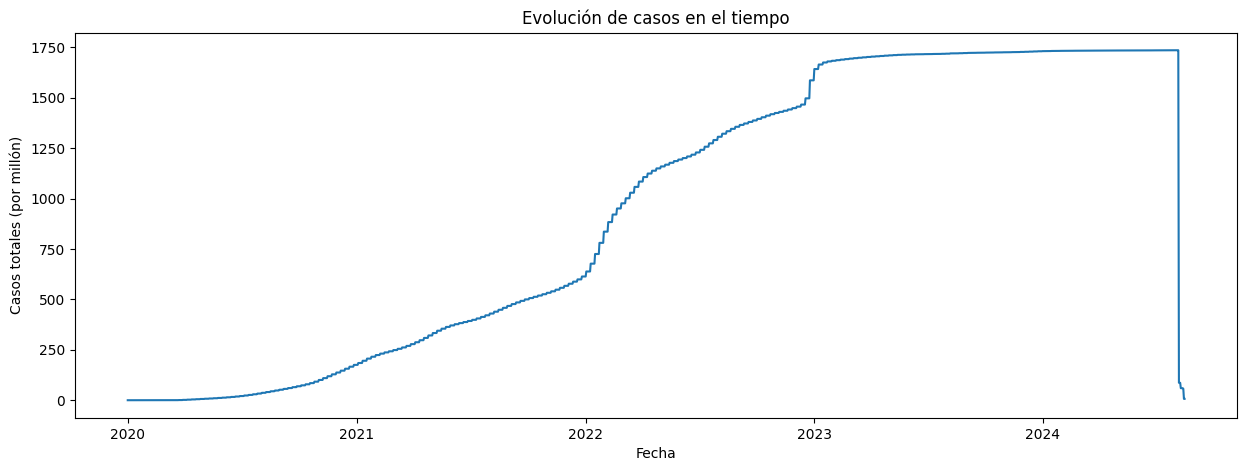

In [23]:
evol_timeotal_cases = df_paises.groupby("date")["total_cases"].sum().reset_index()
# evol_timeotal_cases.plot(x="date", y="total_cases", figsize=(15, 5))
plt.figure(figsize=(15, 5))
plt.plot(evol_timeotal_cases["date"], evol_timeotal_cases["total_cases"] / 1_000_000)
plt.title("Evolución de casos en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Casos totales (por millón)")
plt.show()

### Evolución de muertes en el tiempo

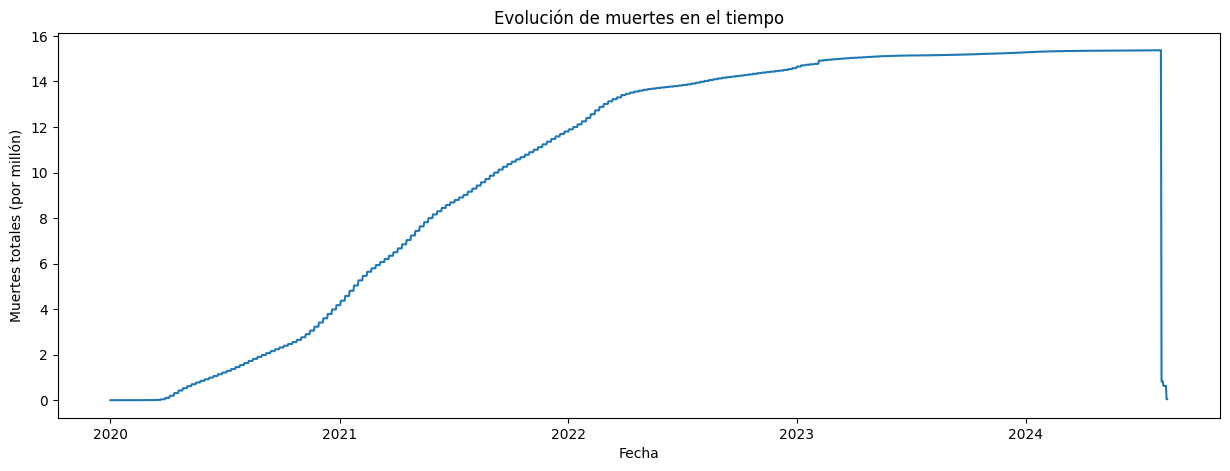

In [24]:
evol_timeotal_deaths = df_paises.groupby("date")["total_deaths"].sum().reset_index()
plt.figure(figsize=(15, 5))
plt.plot(evol_timeotal_deaths["date"], evol_timeotal_deaths["total_deaths"] / 1_000_000)
plt.title("Evolución de muertes en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Muertes totales (por millón)")
plt.show()

### Paises con más casos totales

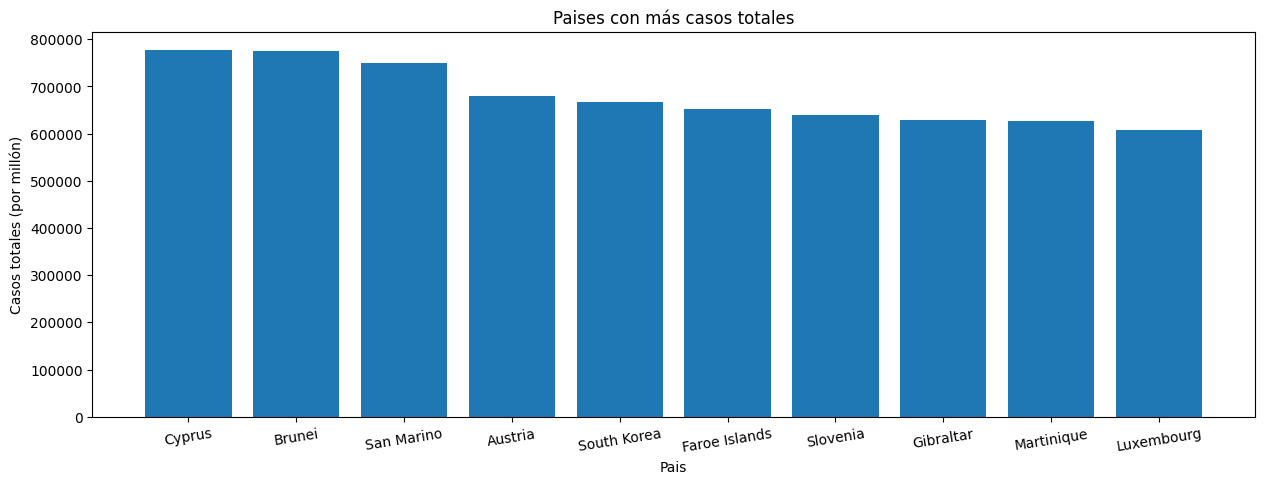

In [26]:
plt.figure(figsize=(15, 5))
# top_case
plt.bar(top_case["location"], top_case["total_cases_per_million"])
plt.title("Paises con más casos totales")
plt.xlabel("Pais")
plt.ylabel("Casos totales (por millón)")
plt.xticks(rotation=9)
plt.show()

### paises con mas muertes

In [30]:
top_10_deaths["location"] = top_10_deaths["location"].replace(
    "Bosnia and Herzegovina", "Bos and Herz"
)
top_10_deaths

,location,total_deaths_per_million
0,Peru,6489.799524
1,Bulgaria,5706.319196
2,Bos and Herz,5069.382378
3,Hungary,4921.390980
4,North Macedonia,4765.939723
5,Slovenia,4756.484325
6,Croatia,4652.684958
7,Georgia,4580.191407
8,Montenegro,4232.301358
9,Czechia,4146.087427


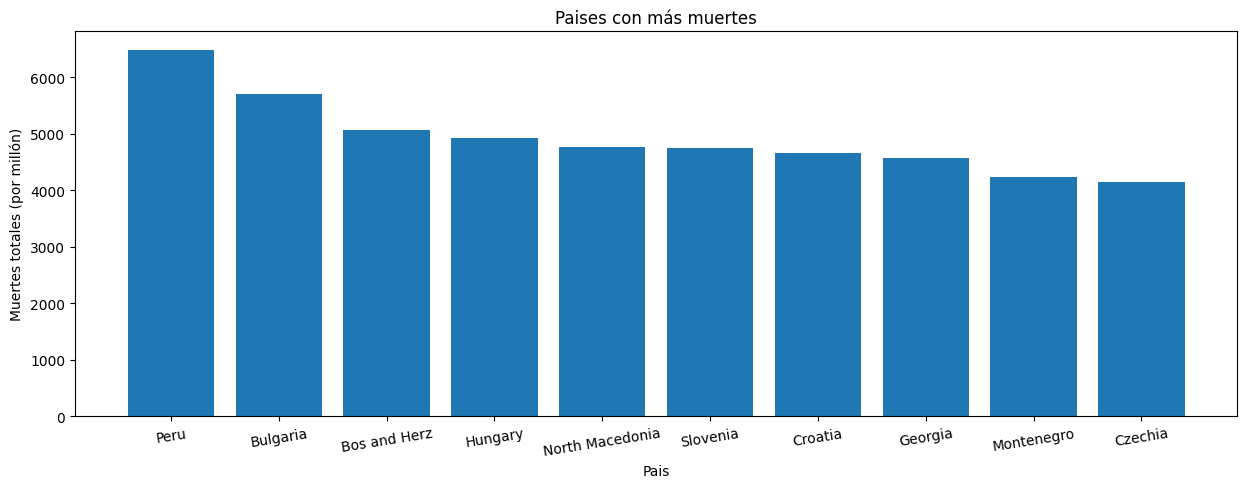

In [31]:
plt.figure(figsize=(15, 5))
plt.bar(top_10_deaths["location"], top_10_deaths["total_deaths_per_million"])
plt.title("Paises con más muertes")
plt.xlabel("Pais")
plt.ylabel("Muertes totales (por millón)")
plt.xticks(rotation=9)
plt.show()